# SRQ4 — Grand Comparison: Baseline, Attention-CNN, Metric Learning, Tokenised Self-Attention, and ViT

Trains EfficientFormer-L1 under the same two-phase transfer learning protocol used for all CNN experiments,
then produces a final five-model synthesis comparison on the held-out test set.

**Models compared in the final test evaluation:**
- `base` — plain ResNet18 + linear head (anchor baseline)
- Best SRQ1 attention variant — best-performing attention-augmented CNN from arch-eval
- Best SRQ2 result — best backbone + NCA+kNN (loaded from nca_knn_test_results.csv)
- Best SRQ3 result — CNN + single MHSA hybrid (loaded from hybrid_test_results.csv)
- `efficientformer` — EfficientFormer-L1 (parameter-matched ViT, this SRQ)

**EfficientFormer protocol:**
- Phase 1 `param_mode='head'`: transformer encoder frozen, only classifier head warms up
- Phase 2 `param_mode='all'`: full fine-tuning with gradient clipping (max_norm=1.0)
- Phase 2 patience increased to 5 (vs 3 for CNNs) — ViTs stabilise slower after unfreezing
- All hyperparameters loaded from `grid-search-results/optimal_config.csv` (same as CNN baseline)
- 5-fold stratified CV; best fold selected by val F1 for test evaluation


## 1 · Paths & Imports

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT  = ABSOLUTE_PATH.parents[1]
DATA_DIR      = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR   = PROJECT_ROOT / "data" / "experiments" / "vit-comparison-results"
WEIGHTS_DIR   = RESULTS_DIR / "weights"
CURVES_DIR    = RESULTS_DIR / "training-curves"
PLOTS_DIR     = RESULTS_DIR / "plots"

# Upstream experiment directories (read-only)
ARCH_EVAL_RESULTS_DIR     = PROJECT_ROOT / "data" / "experiments" / "arch-eval-results"
HEAD_ABLATION_RESULTS_DIR = PROJECT_ROOT / "data" / "experiments" / "head-ablation-results"
GRID_SEARCH_RESULTS_DIR   = PROJECT_ROOT / "data" / "experiments" / "grid-search-results"
NCA_KNN_RESULTS_DIR       = PROJECT_ROOT / "data" / "experiments" / "nca-knn-results"
MHSA_RESULTS_DIR          = PROJECT_ROOT / "data" / "experiments" / "cnn-mhsa-hybrid-results"

for d in [RESULTS_DIR, WEIGHTS_DIR, CURVES_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(f"Project root    : {PROJECT_ROOT}")
print(f"Data dir        : {DATA_DIR}")
print(f"Results dir     : {RESULTS_DIR}")
print(f"Arch-eval dir   : {ARCH_EVAL_RESULTS_DIR}")
print(f"NCA-kNN dir     : {NCA_KNN_RESULTS_DIR}")
print(f"MHSA hybrid dir : {MHSA_RESULTS_DIR}")


Project root    : C:\Users\markm\Workspace\ms-machine-learning-diagnosis
Data dir        : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
Results dir     : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results
Arch-eval dir   : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\arch-eval-results
NCA-kNN dir     : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\nca-knn-results
MHSA hybrid dir : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\cnn-mhsa-hybrid-results


In [2]:
import csv
import time
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import f1_score

import src.scripts.data      as data
import src.scripts.models    as models
import src.scripts.trainer   as trainer
import src.scripts.utils     as utils
import src.scripts.evaluator as evaluator

utils.set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Random seed set to 42 for Python, NumPy, and PyTorch
Device: cpu


## 2 · Data — Outer Split (Identical to All Other Experiments)

Fixed seed 42 outer 80/20 stratified split. All training and model selection operates within `X_trainval`.
The held-out test set is set aside until final evaluation in Section 8.

In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories, visualise=False)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels,
    test_split=0.20,
    SEED=42
)

print(f"\nSRQ4 operates on {len(X_trainval)} train+val samples.")
print("Held-out test set is NOT used until Section 8 (final evaluation).")

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201

SRQ4 operates on 1321 train+val samples.
Held-out test set is NOT used until Section 8 (final evaluation).


## 3 · Configuration

All hyperparameters loaded from `grid-search-results/optimal_config.csv` — identical to the CNN baseline.
Phase 1 parameters are fixed a priori (same as all CNN experiments).
Phase 2 LR and weight decay are the CNN-optimal values from the grid search.
Phase 2 patience is increased from 3 to 5 to allow ViT stabilisation after unfreezing.
Gradient clipping (max_norm=1.0) is applied in Phase 2 — standard practice for ViT fine-tuning.


In [4]:
# ── Load hyperparameters from CNN baseline grid search ───────────────────────
OPTIMAL_CONFIG_FILE = GRID_SEARCH_RESULTS_DIR / "optimal_config.csv"
if not OPTIMAL_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"optimal_config.csv not found at {OPTIMAL_CONFIG_FILE}\n"
        "Run the grid search notebook first."
    )

optimal = pd.read_csv(OPTIMAL_CONFIG_FILE).iloc[0]
LR_PHASE1         = float(optimal["lr_phase1"])
WD_PHASE1         = float(optimal["wd_phase1"])
BEST_LR_PHASE2    = float(optimal["lr_phase2"])
BEST_WEIGHT_DECAY = float(optimal["weight_decay"])

# ── Fixed protocol parameters ─────────────────────────────────────────────────
SEED           = 42
BATCH_SIZE     = 32
WINNING_HEAD   = "linear"
P1_EPOCHS      = 20
P1_PATIENCE    = 4
P2_EPOCHS      = 15
P2_PATIENCE    = 3       
GRAD_CLIP_NORM = 1.0     # standard for ViT fine-tuning; no-op for Phase 1
ARCHITECTURE   = "efficientformer"

print(f"Loaded from : {OPTIMAL_CONFIG_FILE.name}")
print(f"  lr_phase1    = {LR_PHASE1:.0e}")
print(f"  wd_phase1    = {WD_PHASE1}")
print(f"  lr_phase2    = {BEST_LR_PHASE2:.0e}")
print(f"  weight_decay = {BEST_WEIGHT_DECAY:.0e}")
print(f"")
print(f"Architecture : {ARCHITECTURE}")
print(f"Head         : {WINNING_HEAD}")
print(f"Phase 1      : epochs={P1_EPOCHS}  patience={P1_PATIENCE}")
print(f"Phase 2      : epochs={P2_EPOCHS}  patience={P2_PATIENCE}  grad_clip={GRAD_CLIP_NORM}")
print(f"Note         : Phase 2 hyperparameters are CNN-optimal values — same protocol, no separate ViT tuning")


Loaded from : optimal_config.csv
  lr_phase1    = 1e-03
  wd_phase1    = 0.0
  lr_phase2    = 1e-04
  weight_decay = 1e-04

Architecture : efficientformer
Head         : linear
Phase 1      : epochs=20  patience=4
Phase 2      : epochs=15  patience=3  grad_clip=1.0
Note         : Phase 2 hyperparameters are CNN-optimal values — same protocol, no separate ViT tuning


## 4 · 5-Fold CV Training — EfficientFormer

Trains EfficientFormer under the CNN-optimal config using 5-fold stratified CV.
Weights saved per fold. Results saved fold-by-fold; safe to interrupt and resume.


In [5]:
N_SPLITS     = 5
RESULTS_FILE = RESULTS_DIR / "vit_cv_results.csv"
CV_FIELDNAMES = [
    "architecture", "lr_phase1", "wd_phase1", "lr_phase2", "weight_decay",
    "fold", "val_acc", "val_loss", "val_f1",
    "p1_epochs_run", "p2_epochs_run",
    "weights_path", "timestamp", "error"
]

total_cv_runs = N_SPLITS
print(f"EfficientFormer × {N_SPLITS} folds = {total_cv_runs} runs")
print(f"lr_phase2 : {BEST_LR_PHASE2:.0e}  weight_decay : {BEST_WEIGHT_DECAY:.0e}")
print(f"Results   → {RESULTS_FILE}")
print(f"Weights   → {WEIGHTS_DIR}/{ARCHITECTURE}/fold_<n>.pt")

EfficientFormer × 5 folds = 5 runs
lr_phase2 : 1e-04  weight_decay : 1e-04
Results   → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\vit_cv_results.csv
Weights   → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\weights/efficientformer/fold_<n>.pt


In [6]:
completed_cv = utils.load_completed_runs(
    RESULTS_FILE,
    [("architecture", str), ("fold", int)]
)
cv_run_number = len(completed_cv)
print(f"Device: {DEVICE}")
print(f"{N_SPLITS} folds — {cv_run_number} already completed\n")

for fold_idx in range(N_SPLITS):

    run_key = (ARCHITECTURE, fold_idx)
    wpath   = utils.weights_path_for(WEIGHTS_DIR, ARCHITECTURE, fold_idx)

    # Skip if already recorded in CSV
    if run_key in completed_cv:
        print(f"SKIP  fold={fold_idx+1}/{N_SPLITS}  (recorded in CSV)")
        continue

    # Skip if weights file already exists on disk (e.g. CSV was lost)
    if wpath.exists():
        print(f"SKIP  fold={fold_idx+1}/{N_SPLITS}  (weights already exist at {wpath})")
        continue

    utils.set_seed(SEED)
    cv_run_number += 1
    print(f"\n{'='*65}")
    print(f"  Run {cv_run_number}/{total_cv_runs}  |  fold={fold_idx+1}/{N_SPLITS}")
    print(f"{'='*65}")

    error_msg = ""
    val_f1 = val_acc = val_loss = float("nan")
    p1_epochs_run = p2_epochs_run = 0

    try:
        train_loader, val_loader = data.get_fold_loaders(
            X_trainval, y_trainval,
            fold_idx=fold_idx,
            train_transform=train_transform,
            test_transform=test_transform,
            n_splits=N_SPLITS,
            batch_size=BATCH_SIZE,
            SEED=SEED
        )

        model = models.get_model(architecture=ARCHITECTURE, head=WINNING_HEAD)

        run_configs = {
            "phase1": {
                "num_epochs"  : P1_EPOCHS,
                "lr"          : LR_PHASE1,
                "parameters"  : "head",
                "optimiser"   : optim.AdamW,
                "criterion"   : nn.BCEWithLogitsLoss(),
                "weight_decay": WD_PHASE1,
            },
            "phase2": {
                "num_epochs"  : P2_EPOCHS,
                "lr"          : BEST_LR_PHASE2,
                "parameters"  : "all",
                "optimiser"   : optim.AdamW,
                "criterion"   : nn.BCEWithLogitsLoss(),
                "weight_decay": BEST_WEIGHT_DECAY,
            },
        }

        # Phase 1
        losses_p1, accs_p1, val_losses_p1, val_accs_p1 = trainer.train_model(
            model, train_loader, val_loader,
            config_name="phase1",
            train_configs=run_configs,
            early_stopping_patience=P1_PATIENCE
        )
        p1_epochs_run = len(val_accs_p1)

        utils.plot(
            losses_p1, accs_p1,
            config_name=f"phase1_fold{fold_idx}",
            val_losses=val_losses_p1, val_accuracies=val_accs_p1,
            model_name=ARCHITECTURE,
            save_dir=str(CURVES_DIR),
            show=False
        )

        # Phase 2 with gradient clipping
        losses_p2, accs_p2, val_losses_p2, val_accs_p2 = trainer.train_model(
            model, train_loader, val_loader,
            config_name="phase2",
            train_configs=run_configs,
            early_stopping_patience=P2_PATIENCE,
            grad_clip_norm=GRAD_CLIP_NORM
        )
        p2_epochs_run = len(val_accs_p2)

        utils.plot(
            losses_p2, accs_p2,
            config_name=f"phase2_fold{fold_idx}",
            val_losses=val_losses_p2, val_accuracies=val_accs_p2,
            model_name=ARCHITECTURE,
            save_dir=str(CURVES_DIR),
            show=False
        )

        val_loss = val_losses_p2[-1]
        val_acc  = val_accs_p2[-1]

        # Val F1
        model.eval()
        y_true_val, y_pred_val = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs = imgs.to(DEVICE)
                probs = torch.sigmoid(model(imgs)).cpu().numpy().flatten()
                preds = (probs >= 0.5).astype(int)
                y_true_val.extend(lbls.numpy().astype(int))
                y_pred_val.extend(preds)
        val_f1 = f1_score(y_true_val, y_pred_val)

        utils.save_weights(model, wpath)
        print(f"  val_f1={val_f1:.4f}  val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  "
              f"(p1={p1_epochs_run}ep  p2={p2_epochs_run}ep)")
        print(f"  Weights → {wpath}")

    except Exception as e:
        error_msg = str(e)
        print(f"  ERROR: {error_msg}")
        traceback.print_exc()

    utils.append_result(RESULTS_FILE, CV_FIELDNAMES, {
        "architecture" : ARCHITECTURE,
        "lr_phase1"    : LR_PHASE1,
        "wd_phase1"    : WD_PHASE1,
        "lr_phase2"    : BEST_LR_PHASE2,
        "weight_decay" : BEST_WEIGHT_DECAY,
        "fold"         : fold_idx,
        "val_acc"      : round(val_acc, 4) if not np.isnan(val_acc) else "",
        "val_loss"     : round(val_loss, 4) if not np.isnan(val_loss) else "",
        "val_f1"       : round(val_f1, 4) if not np.isnan(val_f1) else "",
        "p1_epochs_run": p1_epochs_run,
        "p2_epochs_run": p2_epochs_run,
        "weights_path" : str(wpath),
        "timestamp"    : datetime.now().isoformat(timespec="seconds"),
        "error"        : error_msg,
    })

print(f"\n{'='*65}")
print("CV TRAINING COMPLETE")
print(f"Results → {RESULTS_FILE}")


Device: cpu
5 folds — 5 already completed

SKIP  fold=1/5  (recorded in CSV)
SKIP  fold=2/5  (recorded in CSV)
SKIP  fold=3/5  (recorded in CSV)
SKIP  fold=4/5  (recorded in CSV)
SKIP  fold=5/5  (recorded in CSV)

CV TRAINING COMPLETE
Results → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\vit_cv_results.csv


## 5 · CV Results Summary


In [7]:
df_cv = pd.read_csv(RESULTS_FILE)
df_cv["error"] = df_cv["error"].fillna("")
df_ok   = df_cv[df_cv["error"] == ""].copy()
df_fail = df_cv[df_cv["error"] != ""].copy()

for col in ["val_f1", "val_acc", "val_loss"]:
    df_ok[col] = df_ok[col].astype(float)

print(f"Successful runs : {len(df_ok)} / {total_cv_runs}")
print(f"Failed runs     : {len(df_fail)}")
if len(df_fail):
    print(df_fail[["fold", "error"]].to_string(index=False))

Successful runs : 5 / 5
Failed runs     : 0


In [8]:
# ── CV comparison vs cbam_block_post ─────────────────────────────────────────────────
arch_eval_csv = ARCH_EVAL_RESULTS_DIR / "arch_eval_results.csv"
CNN_ARCH      = "cbam_block_post"

if arch_eval_csv.exists():
    df_arch = pd.read_csv(arch_eval_csv)
    df_arch["error"] = df_arch["error"].fillna("")
    df_arch = df_arch[(df_arch["error"] == "") & (df_arch["architecture"] == CNN_ARCH)]

    if df_arch.empty:
        print(f"No successful {CNN_ARCH} runs found — comparison skipped")
    else:
        cbam_mean = df_arch["val_f1"].mean()
        print(f"\n  {CNN_ARCH} CV mean F1  : {cbam_mean:.4f}")
        print(f"  ViT CV mean F1      : {df_ok.val_f1.mean():.4f}")
        print(f"  \u0394 (ViT \u2212 {CNN_ARCH})  : {df_ok.val_f1.mean() - cbam_mean:+.4f}")
else:
    print("arch-eval results not found — comparison skipped")



  cbam_block_post CV mean F1  : 0.8991
  ViT CV mean F1      : 0.8652
  Δ (ViT − cbam_block_post)  : -0.0339


In [9]:
# ── Fold selection — best val F1 ──────────────────────────────────────────────
if not df_ok.empty:
    best_fold_row = df_ok.sort_values("val_f1", ascending=False).iloc[0]
    SELECTED_FOLD = int(best_fold_row["fold"])
    print(f"Selected fold {SELECTED_FOLD+1}  "
          f"(val_f1={best_fold_row.val_f1:.4f}  val_loss={best_fold_row.val_loss:.4f})")

Selected fold 1  (val_f1=0.9400  val_loss=0.1731)


## 6 · Final Test Set Evaluation — SRQ4 Grand Comparison

Evaluates five models on the held-out test set — one representative per SRQ plus the plain baseline.
Each model is evaluated exactly once; no decisions are made after this point.

**Models:**
- `base` + best SRQ1 — loaded from `arch_eval_test_results.csv` (Cell 18)
- Best SRQ2 NCA+kNN — loaded from `nca_knn_test_results.csv` (Cell 19)
- Best SRQ3 CNN-MHSA — loaded from `hybrid_test_results.csv` (Cell 20)
- `efficientformer` — evaluated directly from saved fold weights (Cell 17)

All upstream CSVs must exist before running this section (i.e. each prior notebook's
final test evaluation section must have been run and saved).


In [10]:
test_loader  = data.get_test_loader(X_test, y_test, test_transform, batch_size=BATCH_SIZE)
test_results = {}   # populated by each evaluation cell below
print(f"Test loader ready — {len(X_test)} samples")
print(f"Device: {DEVICE}")


get_test_loader()>>> Test loader ready — 331 samples
Test loader ready — 331 samples
Device: cpu


In [11]:
# ── EfficientFormer (SRQ4) — evaluate from saved fold weights ────────────────
print(f"\n{'='*60}")
print(f"  Test evaluation: {ARCHITECTURE}  (fold {SELECTED_FOLD+1})")
print(f"{'='*60}")

vit_weights = utils.weights_path_for(WEIGHTS_DIR, ARCHITECTURE, SELECTED_FOLD)

if not vit_weights.exists():
    print(f"  SKIP — weights not found at {vit_weights}")
else:
    utils.set_seed(SEED)
    vit_model = models.get_model(architecture=ARCHITECTURE, head=WINNING_HEAD)
    vit_model = utils.load_weights(vit_model, vit_weights, device=DEVICE)

    acc, prec, rec, f1, auc, ece, conf, report = evaluator.evaluate_model(
        model=vit_model, test_loader=test_loader, device=DEVICE
    )
    test_results[ARCHITECTURE] = {
        "label"     : "EfficientFormer (SRQ4)",
        "test_f1"   : round(f1,   4), "test_auc" : round(auc,  4),
        "test_ece"  : round(ece,  4), "test_acc" : round(acc,  4),
        "test_prec" : round(prec, 4), "test_rec" : round(rec,  4),
    }
    print(f"  F1={f1:.4f}  AUC={auc:.4f}  ECE={ece:.4f}")



  Test evaluation: efficientformer  (fold 1)
Random seed set to 42 for Python, NumPy, and PyTorch
get_model()>>> architecture='efficientformer'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
Accuracy  : 0.9486
Precision : 0.9913
Recall    : 0.8769
F1        : 0.9306
AUC-ROC   : 0.9827
ECE       : 0.0471  (lower = better calibrated; 0 = perfect)
Confusion Matrix:
 [[200   1]
 [ 16 114]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       201
           1       0.99      0.88      0.93       130

    accuracy                           0.95       331
   macro avg       0.96      0.94      0.94       331
weighted avg       0.95      0.95      0.95       331

  F1=0.9306  AUC=0.9827  ECE=0.0471


In [12]:
# ── Baseline + best SRQ1 — load from arch_eval_test_results.csv ─────────────
ARCH_TEST_FILE = ARCH_EVAL_RESULTS_DIR / "arch_eval_test_results.csv"

if not ARCH_TEST_FILE.exists():
    print(f"SKIP — {ARCH_TEST_FILE.name} not found. Run arch-eval Section 9 first.")
else:
    df_arch_test = pd.read_csv(ARCH_TEST_FILE, index_col=0)
    df_arch_test.index.name = "architecture"

    # ── Baseline ──────────────────────────────────────────────────────────────
    if "base" in df_arch_test.index:
        r = df_arch_test.loc["base"]
        test_results["base"] = {
            "label"    : "Baseline (ResNet18)",
            "test_f1"  : float(r["test_f1"]),  "test_auc" : float(r["test_auc"]),
            "test_ece" : float(r["test_ece"]),  "test_acc" : float(r["test_acc"]),
            "test_prec": float(r["test_prec"]), "test_rec" : float(r["test_rec"]),
        }
        print(f"Loaded baseline       — F1={r['test_f1']:.4f}  AUC={r['test_auc']:.4f}  ECE={r['test_ece']:.4f}")
    else:
        print("WARNING: 'base' not found in arch_eval_test_results.csv")

    # ── Best SRQ1 attention variant (highest test F1, excluding base) ─────────
    srq1_archs = [
        "cbam_end", "cbam_block_pre", "cbam_block_post",
        "se_end", "se_block_pre", "cbam_isolated_end", "cbam_isolated_block_pre"
    ]
    df_srq1 = df_arch_test[df_arch_test.index.isin(srq1_archs)]
    if df_srq1.empty:
        print("WARNING: no SRQ1 architectures found in arch_eval_test_results.csv")
    else:
        BEST_SRQ1_ARCH = df_srq1["test_f1"].astype(float).idxmax()
        r = df_srq1.loc[BEST_SRQ1_ARCH]
        test_results["srq1_best"] = {
            "label"    : f"Best SRQ1 ({BEST_SRQ1_ARCH})",
            "test_f1"  : float(r["test_f1"]),  "test_auc" : float(r["test_auc"]),
            "test_ece" : float(r["test_ece"]),  "test_acc" : float(r["test_acc"]),
            "test_prec": float(r["test_prec"]), "test_rec" : float(r["test_rec"]),
        }
        print(f"Loaded SRQ1 best ({BEST_SRQ1_ARCH}) — F1={r['test_f1']:.4f}  AUC={r['test_auc']:.4f}  ECE={r['test_ece']:.4f}")


Loaded baseline       — F1=0.9147  AUC=0.9855  ECE=0.0463
Loaded SRQ1 best (cbam_block_post) — F1=0.9407  AUC=0.9883  ECE=0.0369


In [13]:
# ── Best SRQ2 — load from nca_knn_test_results.csv ──────────────────────────
# Note: kNN produces no calibrated probabilities, so AUC and ECE are NaN.
# This is reflected faithfully in the comparison table and visualisation.
NCA_TEST_FILE = NCA_KNN_RESULTS_DIR / "nca_knn_test_results.csv"

if not NCA_TEST_FILE.exists():
    print(f"SKIP — {NCA_TEST_FILE.name} not found. Run nca-knn-eval final evaluation first.")
else:
    df_nca_test = pd.read_csv(NCA_TEST_FILE, index_col=0)
    BEST_NCA_BACKBONE = df_nca_test["test_f1"].astype(float).idxmax()
    r = df_nca_test.loc[BEST_NCA_BACKBONE]
    test_results["srq2_best"] = {
        "label"    : f"Best SRQ2 NCA+kNN ({BEST_NCA_BACKBONE})",
        "test_f1"  : float(r["test_f1"]),
        "test_auc" : float("nan"),   # kNN has no calibrated probabilities
        "test_ece" : float("nan"),
        "test_acc" : float("nan"),   # not saved in nca_knn_test_results
        "test_prec": float("nan"),
        "test_rec" : float("nan"),
    }
    print(f"Loaded SRQ2 best ({BEST_NCA_BACKBONE}) — F1={r['test_f1']:.4f}  (AUC/ECE not available for kNN)")


Loaded SRQ2 best (se_end) — F1=0.9375  (AUC/ECE not available for kNN)


In [14]:
# ── Best SRQ3 — load from hybrid_test_results.csv ───────────────────────────
HYBRID_TEST_FILE = MHSA_RESULTS_DIR / "hybrid_test_results.csv"

if not HYBRID_TEST_FILE.exists():
    print(f"SKIP — {HYBRID_TEST_FILE.name} not found. Run cnn-mhsa-hybrid final evaluation first.")
else:
    df_hybrid_test = pd.read_csv(HYBRID_TEST_FILE)
    r = df_hybrid_test.sort_values("test_f1", ascending=False).iloc[0]
    backbone_name = r["backbone_arch"]
    test_results["srq3_best"] = {
        "label"    : f"Best SRQ3 CNN-MHSA ({backbone_name})",
        "test_f1"  : float(r["test_f1"]),  "test_auc" : float(r["test_auc"]),
        "test_ece" : float(r["test_ece"]),  "test_acc" : float(r["test_acc"]),
        "test_prec": float(r["test_prec"]), "test_rec" : float(r["test_rec"]),
    }
    print(f"Loaded SRQ3 ({backbone_name}) — F1={r['test_f1']:.4f}  AUC={r['test_auc']:.4f}  ECE={r['test_ece']:.4f}")


Loaded SRQ3 (base) — F1=0.9132  AUC=0.9870  ECE=0.0547


In [15]:
# ── Grand comparison table ───────────────────────────────────────────────────
# Display order: baseline → SRQ1 → SRQ2 → SRQ3 → SRQ4 (ViT)
DISPLAY_ORDER = ["base", "srq1_best", "srq2_best", "srq3_best", ARCHITECTURE]

rows = []
for key in DISPLAY_ORDER:
    if key in test_results:
        r = test_results[key]
        rows.append({
            "Model"    : r["label"],
            "Test F1"  : r["test_f1"],
            "AUC-ROC"  : r["test_auc"],
            "ECE"      : r["test_ece"],
            "Accuracy" : r["test_acc"],
            "Precision": r["test_prec"],
            "Recall"   : r["test_rec"],
        })

df_test = pd.DataFrame(rows)

print("SRQ4 — Grand Comparison: Final Test Results\n")
print(f"{'Model':<45} {'F1':>8} {'AUC-ROC':>9} {'ECE':>8} {'Acc':>8}")
print("-" * 80)
for _, row in df_test.iterrows():
    auc_str = f"{row['AUC-ROC']:>9.4f}" if not np.isnan(row['AUC-ROC']) else "      N/A"
    ece_str = f"{row['ECE']:>8.4f}"     if not np.isnan(row['ECE'])     else "     N/A"
    acc_str = f"{row['Accuracy']:>8.4f}" if not np.isnan(row['Accuracy']) else "     N/A"
    print(f"  {row['Model']:<43} {row['Test F1']:>8.4f} {auc_str} {ece_str} {acc_str}")

# Delta vs baseline
if "base" in test_results:
    base_f1 = test_results["base"]["test_f1"]
    print(f"\n  Δ vs baseline (base ResNet18):")
    for key in ["srq1_best", "srq2_best", "srq3_best", ARCHITECTURE]:
        if key in test_results:
            r = test_results[key]
            delta = r["test_f1"] - base_f1
            print(f"    {r['label']:<43}: ΔF1 = {delta:+.4f}")


SRQ4 — Grand Comparison: Final Test Results

Model                                               F1   AUC-ROC      ECE      Acc
--------------------------------------------------------------------------------
  Baseline (ResNet18)                           0.9147    0.9855   0.0463   0.9335
  Best SRQ1 (cbam_block_post)                   0.9407    0.9883   0.0369   0.9547
  Best SRQ2 NCA+kNN (se_end)                    0.9375       N/A      N/A      N/A
  Best SRQ3 CNN-MHSA (base)                     0.9132    0.9870   0.0547   0.9305
  EfficientFormer (SRQ4)                        0.9306    0.9827   0.0471   0.9486

  Δ vs baseline (base ResNet18):
    Best SRQ1 (cbam_block_post)                : ΔF1 = +0.0260
    Best SRQ2 NCA+kNN (se_end)                 : ΔF1 = +0.0228
    Best SRQ3 CNN-MHSA (base)                  : ΔF1 = -0.0015
    EfficientFormer (SRQ4)                     : ΔF1 = +0.0159


In [16]:
# ── Save grand comparison results ────────────────────────────────────────────
TEST_RESULTS_FILE = RESULTS_DIR / "srq4_test_results.csv"
df_test.to_csv(TEST_RESULTS_FILE, index=False)
print(f"Test results saved → {TEST_RESULTS_FILE}")


Test results saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\srq4_test_results.csv


save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\plots\srq4_test_results.png
save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\plots\srq4_test_results.svg


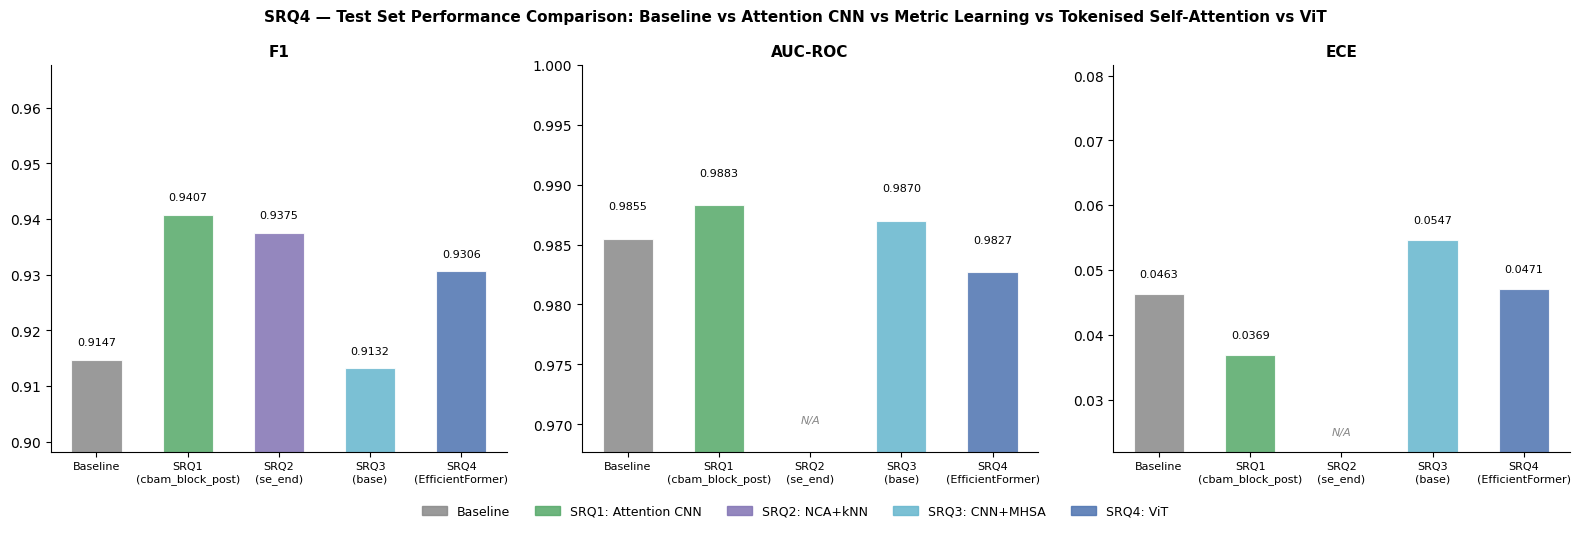

In [26]:
# ── Visualisation — grand comparison bar chart ────────────────────────────────
if not df_test.empty:
    COLOUR_MAP = {"Baseline (ResNet18)": "#888888"}
    SRQ_COLOURS = ["#55A868", "#8172B3", "#64B5CD", "#4C72B0"]

    colours = []
    for _, row in df_test.iterrows():
        label = row["Model"]
        if label in COLOUR_MAP:
            colours.append(COLOUR_MAP[label])
        elif "SRQ1" in label:
            colours.append(SRQ_COLOURS[0])
        elif "SRQ2" in label:
            colours.append(SRQ_COLOURS[1])
        elif "SRQ3" in label:
            colours.append(SRQ_COLOURS[2])
        else:
            colours.append(SRQ_COLOURS[3])

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        "SRQ4 — Test Set Performance Comparison: Baseline vs Attention CNN vs Metric Learning vs "
        "Tokenised Self-Attention vs ViT",
        fontsize=11, fontweight="bold"
    )
    labels = df_test["Model"].tolist()
    x      = np.arange(len(labels))
    w      = 0.55
    short_labels = [
        l.replace("Baseline (ResNet18)", "Baseline")
         .replace("Best SRQ1 ", "SRQ1\n")
         .replace("Best SRQ2 NCA+kNN ", "SRQ2\n")
         .replace("Best SRQ3 CNN-MHSA ", "SRQ3\n")
         .replace("EfficientFormer (SRQ4)", "SRQ4\n(EfficientFormer)")
        for l in labels
    ]

    metrics = [
        ("Test F1",  "F1",        axes[0]),
        ("AUC-ROC",  "AUC-ROC",        axes[1]),
        ("ECE",      "ECE", axes[2]),
    ]

    for col, title, ax in metrics:
        vals  = df_test[col].values.astype(float)
        valid = vals[~np.isnan(vals)]

        if len(valid) == 0:
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                    ha="center", va="center", fontsize=10, color="grey")
            continue

        ax.bar(x, vals, width=w, color=colours, alpha=0.85,
               edgecolor="white", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, rotation=0, ha="center", fontsize=8)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)

        rng = valid.max() - valid.min()
        pad = max(rng * 0.3, 0.015)
        ax.set_ylim(max(0, valid.min() - pad), min(1.0, valid.max() + pad * 1.8))
        y_bottom = ax.get_ylim()[0]

        for xi, v in zip(x, vals):
            if np.isnan(v):
                ax.text(xi, y_bottom + pad * 0.15, "N/A", ha="center", va="bottom",
                        fontsize=8, color="#888888", fontstyle="italic")
            else:
                ax.text(xi, v + pad * 0.15, f"{v:.4f}", ha="center", va="bottom",
                        fontsize=8)

    legend_entries = [
        ("Baseline",            "#888888"),
        ("SRQ1: Attention CNN", SRQ_COLOURS[0]),
        ("SRQ2: NCA+kNN",       SRQ_COLOURS[1]),
        ("SRQ3: CNN+MHSA",      SRQ_COLOURS[2]),
        ("SRQ4: ViT",           SRQ_COLOURS[3]),
    ]
    handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.85, label=l)
               for l, c in legend_entries]
    fig.legend(handles=handles, loc="lower center", ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.06), frameon=False)

    plt.tight_layout()
    utils.save_fig(fig, PLOTS_DIR, "srq4_test_results")
    plt.show()
